<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif;">

<h1 style="color: #004080; border-bottom: 3px solid #004080; padding-bottom: 10px; font-weight: 800; margin-top: 0;">
    Aquaverse Short Course Part I: Mixture Density Networks (MDNs)
</h1>

<p style="font-size: 1.15em; line-height: 1.7; color: #222222;">
    This notebook introduces the <b>Mixture Density Network (MDN)</b> framework. MDNs are a powerful variant of neural networks that estimate outputs as a <b>probability distribution</b> rather than a single point value. This is a vital distinction for solving <b>inverse physical problems</b>—where a single observation may correspond to multiple physical states—and allows the model to provide a robust estimate of <b>predictive uncertainty</b>.
</p>

<p style="font-size: 1.15em; line-height: 1.7; color: #222222;">
    Selected WQ products generated using our MDN pipelines are available for visualization and download via NASA's <a href="https://ladsweb.modaps.eosdis.nasa.gov/stream/" target="_blank" style="color:#0056b3;text-decoration:underline;font-weight:bold;"> Satellite-based Tool for Rapid Evaluation of Aquatic environMents (STREAM)</a> website.
</p>



<h3 style="color: #004080; margin-top: 25px;"><b>Course Objectives</b></h3>
<ul style="line-height: 1.9; color: #1a1a1a; list-style-type: none; padding-left: 0;">
    <li><span style="color: #d35400;">■</span> <b>01. Environment Setup:</b> Import the SSAI Freshwater Sensing Group's MDN distribution.</li>
    <li><span style="color: #d35400;">■</span> <b>02. Data Acquisition:</b> Download the <a href="https://doi.pangaea.de/10.1594/PANGAEA.948492" target="_blank" style="color: #0056b3; text-decoration: underline; font-weight: bold;">GLORIA dataset</a>—a collection of collocated <i>in situ</i> Remote Sensing Reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>) and Water Quality (WQ) variables.</li>
    <li><span style="color: #d35400;">■</span> <b>03. Architecture:</b> Understand MDN structures and output parameterization.</li>
    <li><span style="color: #d35400;">■</span> <b>04. Biogeochemical Prediction:</b> Extract WQ parameters from Remote Sensing Reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>).</li>
    <li><span style="color: #d35400;">■</span> <b>05. Uncertainty Analysis:</b> Visualize MDN outputs, explain how point estimates are derived, and demonstrate how to quantify predictive uncertainty.</li>
</ul>

<div style="background-color: #fcf8e3; color: #8a6d3b; padding: 15px; border: 1px solid #faebcc; border-left: 6px solid #8a6d3b; margin: 20px 0; font-weight: 500;">
    <strong>Requirement:</strong> Please run all sections in sequential order to maintain data integrity and variable definitions.
</div>

<hr style="border: 0; border-top: 2px solid #eee;">

<div style="margin-bottom: 20px;">
    <strong style="color: #004080; font-size: 1.1em;">Freshwater Sensing Group</strong><br>
    <span style="color: #444;">Science Systems and Applications, Inc. / NASA Goddard Space Flight Center</span><br>
    <span style="color: #666;">August 2026</span>
</div>

<h4 style="color: #004080; margin-bottom: 10px;">Technical Contacts</h4>
<table style="width: 100%; border-collapse: collapse; border: 1px solid #ddd;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Domain</th>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Section Lead</th>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Email</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">BPs & IOP Products</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Ryan E. O'Shea</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:ryan.oshea@ssaihq.com" style="color: #0056b3; font-weight: bold;">ryan.oshea@ssaihq.com</a></td>
        </tr>
        <tr style="background-color: #fafafa;">
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Uncertainties</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Arun Saranathan</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:arun.saranathan@ssaihq.com" style="color: #0056b3; font-weight: bold;">arun.saranathan@ssaihq.com</a></td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Atmospheric Correction</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Akash Ashapure</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:akash.ashapure@ssaihq.com" style="color: #0056b3; font-weight: bold;">akash.ashapure@ssaihq.com</a></td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Stream Website</td>
            <td style="padding: 10px; border: 1px solid #ddd;">William Wainwright</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:william.wainwright@ssaihq.com" style="color: #0056b3; font-weight: bold;">william.wainwright@ssaihq.com</a></td>
        </tr>
    </tbody>
</table>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 1: MDN Package Import and Verification
</h2>

<p style="font-size: 1.15em; color: #222222;">
    A <b>TensorFlow-based</b> implementation of Mixture Density Networks is provided via the custom <code>MDN</code> package included with this course. To begin, we must initialize the environment by importing the specific modules required for model architecture construction, weight loading, and spectral preprocessing.
</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0;">
    <strong style="font-size: 1.1em;">Technical Note:</strong> 
    The import process verifies that your local environment has the necessary <b>TensorFlow</b> and <b>TensorFlow Probability</b> dependencies configured correctly to handle the stochastic nature of the MDN output layer.
</div>

<p style="font-size: 1.1em; color: #222222;">
    Please run the following code cell to load the core functions and verify that the package is accessible within your current Python kernel.
</p>

<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 1.1
</div>

</div>

In [1]:
# Import the base python packages needed for this notebook
import numpy                                                          as np
import scipy
import os
import subprocess
from   pathlib                    import Path
from   urllib.request             import urlretrieve
import zipfile
import matplotlib                                                     as mpl
import matplotlib.pyplot                                              as plt
import matplotlib.patches                                             as patches
from   matplotlib                 import ticker
from   matplotlib.colors          import LogNorm
import sys
sys.path.append("C:\\Users\\asaranat\\OneDrive - NASA\\Code\\MDN-STREAM\\")

# Supressing tensorflow based warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('tensorflow_probability').setLevel(logging.ERROR)

# Import some specific functions and packages from MDN implementation
from   MDN                        import get_sensor_bands, get_tile_data
from   MDN                        import current_support 
from   MDN                        import get_gloria_trainTestData, get_args
from   MDN                        import get_spectral_preds_raw
from   MDN                        import create_scatterplots_trueVsPred, performance
from   MDN                        import OC, resample_Rrs 

[compat_patch] NumPy version: 2.3.3
[compat_patch] Applied NumPy _randomstate_ctor patch.
[compat_patch] TensorFlow version: 2.20.0
[compat_patch] Applied TensorFlow TrackableReference patch (tracking.base).
[compat_patch] NumPy version: 2.3.3
[compat_patch] TensorFlow version: 2.20.0
Modified RC Params: dict_keys(['backend'])


In [2]:
# Set display parameters via MATPLOTLIB for this notebook
plt.rcParams.update({"text.usetex": False,})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['mathtext.default'] = 'regular'
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
mrkSize = 15
ASPECT = "auto"
cmap = "jet"

mpl.rcParams['xtick.labelsize'] = SMALL_SIZE
mpl.rcParams['ytick.labelsize'] = SMALL_SIZE

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 2: Download and Process the GLORIA Dataset
</h2>

<p style="font-size: 1.15em; color: #222222;">
    To evaluate the MDN's operation and performance, we will utilize the 
    <a href="https://doi.pangaea.de/10.1594/PANGAEA.948492" target="_blank" style="color: #0056b3; text-decoration: underline; font-weight: bold;">
        GLObal Reflectance community dataset for Imaging and optical sensing of Aquatic environments (GLORIA)
    </a>.
</p>

<p style="font-size: 1.1em; color: #222222;">
    GLORIA is a comprehensive, globally distributed <i>in situ</i> dataset specifically designed for the training and the validation of aquatic remote sensing algorithms. It provides the collocated pairs of hyperspectral/multispectral Remote Sensing Reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>) and corresponding water quality measurements required to test the predictive capabilities of the MDN.
</p>

<div style="background-color: #eafaf1; color: #145a32; padding: 15px; border: 1px solid #d4efdf; border-left: 6px solid #27ae60; margin: 20px 0;">
    <strong style="font-size: 1.1em;">Action Required:</strong> 
    The following cells will automate the download from the PANGAEA repository and perform the necessary spectral subsetting to match the sensor dimensions expected by the MDN architecture.
</div>

<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 1.2
</div>

</div>

In [3]:
# Define the path where the dataset will be stored
zip_path = os.path.join("data", "GLORIA-2022.zip")

# Check if the file exists; if not, create the directory and download
if not os.path.exists(zip_path):
    os.makedirs("data", exist_ok=True)
    print(f"Downloading GLORIA dataset to {zip_path}...")
    subprocess.run([
        "curl",
        "-L",
        "-o", zip_path,
        "https://download.pangaea.de/dataset/948492/files/GLORIA-2022.zip"
    ], check=True)
    print("Download complete.")
else:
    print("Dataset already exists locally.")

Dataset already exists locally.


In [4]:
# Set up the paths for the GLORIA dataset
zip_file_path = 'data/GLORIA-2022.zip'
extract_to_dir = 'data/'

# Ensure the extraction directory exists
os.makedirs(extract_to_dir, exist_ok=True)

print(f"Extracting {zip_file_path}...")

# Unzip the downloaded dataset
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_dir)
    print(f'Successfully extracted files to: {extract_to_dir}')

Extracting data/GLORIA-2022.zip...
Successfully extracted files to: data/


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<p style="font-size: 1.15em; color: #222222; margin-top: 0;">
    The GLORIA dataset contains hyperspectral <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> samples spanning 350–800 nm, interpolated to a 1 nm resolution. To ensure the MDN models are compatible with specific Ocean Color (OC) satellite sensors, we must perform <b>spectral resampling</b>.
</p>



<p style="font-size: 1.1em; color: #222222;">
    This process utilizes the instrument's <b>Relative Spectral Response (RsR)</b> function to weight the hyperspectral data according to the sensitivity of each satellite band. Following resampling, the data is partitioned into two distinct subsets:
</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0;">
    <strong style="font-size: 1.1em;">Methodology Note:</strong> 
    By resampling to the RsR of specific missions (e.g., PACE, Landsat-8, Sentinel-3), we ensure that the MDN can be operationally applied to real-world satellite imagery. The full list of supported sensors can be seen below.
</div>

</div>

In [5]:
# Set the GLORIA folder and extract the data
gloria_folder = Path().cwd() / 'data/GLORIA_2022/'

assert gloria_folder.is_dir(), f"No folder found art {gloria_folder}"

# Set the sensor we want to work with
sensor = "OLCI"

# Get the GLORIA data at the resolution of the OLCI sensor
x_data, y_data, gid_data = get_gloria_trainTestData(sensor=sensor, out_var=["chl"],
                                                    save_flag=False, load_exists=False,rand_seed=42,
                                                    rem_flagged=True, gloria_folder=gloria_folder,
                                                    flag_name='GLORIA_qc_flags.csv', rrs_name='GLORIA_Rrs.csv',
                                                    bg_name='GLORIA_meta_and_lab.csv', gloria_only=True,
                                                    train_mode=False)

# Get the wavelengths available for this sensor
wvl_bands = get_sensor_bands("OLCI")

Bands with responses outside of range [350, 899]: 
 [np.float64(900.0), np.float64(940.0), np.float64(1020.0)]

Creating data for bands
 [np.float64(400.0), np.float64(412.5), np.float64(442.5), np.float64(490.0), np.float64(510.0), np.float64(560.0), np.float64(620.0), np.float64(665.0), np.float64(673.75), np.float64(681.25), np.float64(708.75), np.float64(753.75), np.float64(761.25), np.float64(764.375), np.float64(767.5), np.float64(778.75), np.float64(865.0), np.float64(885.0)]


100%|██████████| 7572/7572 [00:05<00:00, 1267.87it/s]


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<p style="font-size: 1.1em; color: #222222;">
    We will start by selecting two samples from the GLORIA database and visualize the effect of applying the MDN package to these two samples. For visualization we will consider two spectra showing different water conditions. Sample-1 (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">GID-1367</span>) which is from a location with intermediate amount of chlorophyll-a. On the other hand Sample-2 (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">GID-2794</span>) shows a sample from a highly eutrophic location. Let us first extract and visualize these samples spectrally.
</p>

</div>

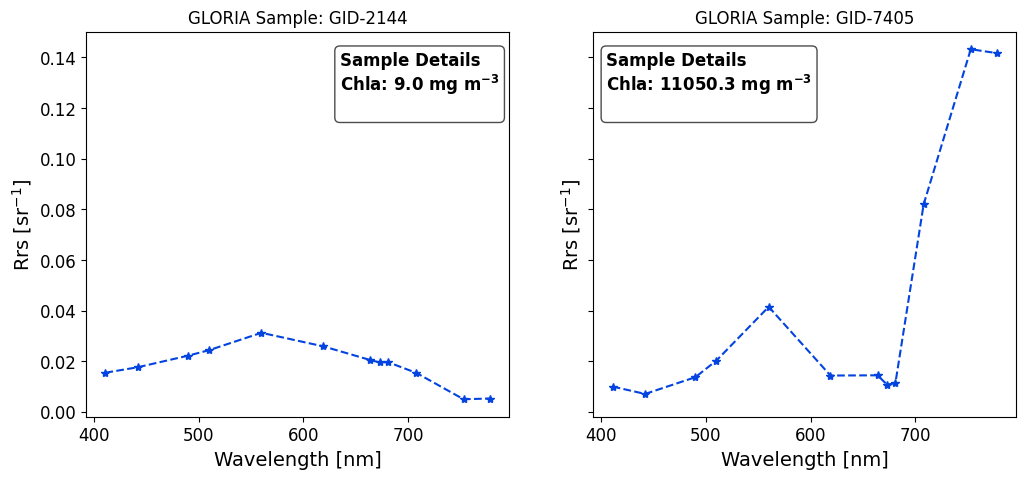

In [6]:
# Visualize a sample from the Gloria data
idx_1 = np.where(gid_data == "GID_2144")[0]    #np.random.choice(x_data.shape[0])
idx_2 = np.where(gid_data == "GID_7405")[0]

fig1, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5), sharey=True)
ax[0].plot(wvl_bands, np.squeeze(x_data[idx_1, :]), linestyle="--", marker="*", color="xkcd:blue")
ax[0].set_title("GLORIA Sample: " + gid_data[idx_1][0].replace('_', '-'));
ax[0].set_xlabel('Wavelength [nm]');
ax[0].set_ylabel(r'Rrs [$sr^{-1}$]');

label= []
for item in y_data[idx_1, :][0]:
    if np.isnan(item):
        label += ['N/A']
    else:
        label+= [f'{item:.1f}']

if plt.rcParams['text.usetex']:
    textstr1 = (r"\underline{\textbf{Sample Details}}" + '\n' + r"\textbf{Chla}:" + f' {label[0]} ' + r"$mg~m^{-3}$" + '\n')
else:
    textstr1 = (r"Sample Details" + '\n' + r"Chla:" + f' {label[0]} ' + r"$mg~m^{-3}$" + '\n')

    #+ r"\textbf{TSS:}" + f'           {label[1]} ' + r"$mg~m^{-3}$" + '\n'  + r"\textbf{acdom:}" + f'    {label[2]} ' + r"$m^{-1}$ " + '\n');
props = dict(boxstyle='round', facecolor='white', alpha=0.7)
ax[0].text(0.6, 0.95, textstr1, transform=ax[0].transAxes, fontsize=SMALL_SIZE*1, weight="bold", verticalalignment='top', bbox=props);

ax[1].plot(wvl_bands, np.squeeze(x_data[idx_2, :]), linestyle="--", marker="*", color="xkcd:blue")
ax[1].set_title("GLORIA Sample: " + gid_data[idx_2][0].replace('_', '-'));
ax[1].set_xlabel('Wavelength [nm]');
ax[1].set_ylabel(r'Rrs [$sr^{-1}$]');

label= []
for item in y_data[idx_2, :][0]:
    if np.isnan(item):
        label += ['N/A']
    else:
        label+= [f'{item:.1f}']
        
if plt.rcParams['text.usetex']:
    textstr1 = (r"\underline{\textbf{Sample Details}}" + '\n' + r"\textbf{Chla}:" + f' {label[0]} ' + r"$mg~m^{-3}$" + '\n')
else:
    textstr1 = (r"Sample Details" + '\n' + r"Chla:" + f' {label[0]} ' + r"$mg~m^{-3}$" + '\n')

    #+ r"\textbf{TSS:}" + f'           {label[1]} ' + r"$mg~m^{-3}$" + '\n'  + r"\textbf{acdom:}" + f'    {label[2]} ' + r"$m^{-1}$ " + '\n');
props = dict(boxstyle='round', facecolor='white', alpha=0.7)
ax[1].text(0.03, 0.95, textstr1, transform=ax[1].transAxes, fontsize=SMALL_SIZE*1, weight="bold", verticalalignment='top', bbox=props);

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<p style="font-size: 1.15em; color: #222222; margin-top: 0;">
    Now that we have GLORIA <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> and are able resample them according to the Rrs of a specific instrument for e.g. <b>Sentinel-3 OLCI</b> (Ocean and Land Colour Instrument) resolution, we are ready to proceed with model inference.
</p>


<p style="font-size: 1.1em; color: #222222;">
    In the following steps, we will use the trained MDN to generate predictions for every spectrum in the GLORIA database. Our primary focus will be <b>evaluating the MDN's performance</b> using the independent test dataset—benchmarking how well the predicted probability distributions align with the <i>in situ</i> observations.
</p>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 3: A Brief Introduction to Inverse Modeling and MDNs
</h2>

<p style="font-size: 1.1em; color: #222222;">
    Classical ML-based regression algorithms typically assume that the causal factors affecting a system are known, and the model attempts to predict a <b>dependent variable</b>. In aquatic optics, Biogeochemical Parameters (BPs) and Inherent Optical Properties (IOPs) are the causal factors that dictate the color of the water column. However, Ocean Color (OC) sensors measure the result of these factors in the form of Remote Sensing Reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>).
</p>

<p style="font-size: 1.1em; color: #222222;">
    Inferring BPs and IOPs from <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> is known as an <b>Inverse Problem</b> (Mobley et al., 1994). These systems are often "Many-to-One"—meaning multiple combinations of water constituents can produce the same spectral signature. This results in a <b>multi-modal</b> output distribution. Because classical ML models assume a single, unimodal output for every input, they are often ill-suited for the ambiguities inherent in inverse modeling.
</p>



<p style="font-size: 1.1em; color: #222222;">
    <b>Mixture Density Networks (MDNs)</b> (Bishop, 1994) address this by predicting a <b>probability distribution</b> rather than a single point estimate. Specifically, MDNs output a <b>Mixture of Gaussians (MoG)</b>, which can represent arbitrarily complex distributions. Recent literature demonstrates that MDN-generated estimates are particularly robust in optically complex eutrophic inland and coastal waters, frequently outperforming classical ML models and operational band-ratio algorithms (Smith et al., 2020; Pahlevan et al., 2021; O'Shea et al., 2023).
</p>

<h4 style="color: #004080; margin-top: 20px;"><b>The Processing Pipeline</b></h4>
<p style="font-size: 1.05em; color: #222222;">
    As shown in <b>Fig. 1</b>, the pipeline follows a structured path:
    <ul style="padding-left: 20px;">
        <li><b>Feature Engineering:</b> Proven Band Ratios (BRs) and Line Heights (LHs) are calculated and appended to the input <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>.</li>
        <li><b>Normalization & Processing:</b> Inputs are normalized and passed through a deep neural network.</li>
        <li><b>Mixture Output:</b> The final layer generates parameters (mean, standard deviation, and mixing coefficient) for multiple Gaussian components.</li>
        <li><b>Product Retrieval:</b> The final estimate is derived via a combination function—typically selecting the mean of the most probable Gaussian component.</li>
    </ul>
</p>

<center>
<div style="border: 2px solid #2c3e50; padding: 15px; border-radius: 8px; width: fit-content; background-color: #f9f9f9; margin-top: 20px;">
    <img src="images/oshea_mdn_pipeline.jpg" alt="MDN processing pipeline" style="width: 800px; display: block; margin-bottom: 10px; border: 1px solid #ddd;" />
        Fig. 1: MDN pipeline for estimating BPs/IOPs from <span style="font-family: 'Times New Roman', serif; font-style: italic;">R<sub>rs</sub></span> (adapted from O'Shea et al., 2023).
    </div>
</div>
</center>

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 1.3
</div>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
Section 4: Using MDN to Extract Biogeochemical Predictions
</h2>

<p style="font-size: 1.1em; color: #222222;">
In this stage of the workflow, we transition from examining the internal mechanics of the model to <b>operational application</b>. This section focuses on applying the Mixture Density Network to the resampled reflectance data to generate actual environmental products.
</p>

<p style="font-size: 1.1em; color: #222222;">
The process involves passing the processed Rrs​ spectra through the MDN architecture to retrieve the specific mixture parameters—<b>means</b>, <b>variances</b>, and <b>mixing weights</b>. These parameters are then synthesized into final biogeochemical estimates, providing not just a single value, but a statistically grounded prediction for each sample.
</p>

<div style="background-color: #f4eefd; color: #5b2c91; padding: 15px; border: 1px solid #e1d5f5; border-left: 6px solid #5b2c91; margin: 25px 0;">
<strong style="font-size: 1.1em;">Current Objective:</strong>
We will now feed the resampled reflectance spectra into the MDN architecture to derive the final biogeochemical estimates and compare these predictions against the true <i>in-situ</i> values to validate model performance.
</div>

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
Aquaverse Short Course • Module 1.4
</div>

</div>

In [10]:
# Get the predictions of the default model for this sensor and product
mdn_preds_full, mdn_uncert_full, mdn_preds_desc = get_spectral_preds_raw(test_x=np.squeeze(x_data[[idx_1, idx_2], :]), sensor=sensor, products='chl')

print("\nRaw MDN Predictions components:")
for item in mdn_preds_full:
    print(item)

Processing MDN ensemble for uncertainty: 100%|██████████| 10/10 [00:00<00:00, 6288.31it/s]


Raw MDN Predictions components:
scalerx
scalery
coefs


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<p style="font-size: 1.1em; color: #222222;">
The various outputs generated by the full MDN architecture are structured as follows:
</p>

<div style="margin-left: 10px;">
<p style="margin-bottom: 8px;">
1. <code style="font-family: 'Courier New', Courier, monospace; background-color: #f4f4f4; padding: 2px 5px; border-radius: 4px; color: #c0392b; font-weight: bold;">scalerx</code>:
To optimize model performance, the MDN utilizes an input data scaler. This output contains the <code>sklearn</code> scaler object used to transform the Rrs​ data.
</p>

<p style="margin-bottom: 8px;">
    2. <code style="font-family: 'Courier New', Courier, monospace; background-color: #f4f4f4; padding: 2px 5px; border-radius: 4px; color: #c0392b; font-weight: bold;">scalery</code>: 
    Similarly, an output data scaler is employed to improve convergence. This contains the <code>sklearn</code> scaler object for the target variable (e.g., Chl-<i>a</i>).
</p>

<p style="margin-bottom: 8px;">
    3. <code style="font-family: 'Courier New', Courier, monospace; background-color: #f4f4f4; padding: 2px 5px; border-radius: 4px; color: #c0392b; font-weight: bold;">coefs</code>: 
    This variable contains the predicted coefficients of the <b>Mixture of Gaussians (MoG)</b> for each sample in the ensemble. The <code>coefs</code> variable is partitioned into three fundamental components:
</p>

</div>

<ul style="padding-left: 40px; font-size: 1.05em; color: #222222; list-style-type: square;">
<li style="margin-bottom: 10px;">
<b>Weights (π):</b> The relative contribution of each Gaussian component. With the number of components (K) set to 5, this is a 5-dimensional vector where ∑π=1.
</li>
<li style="margin-bottom: 10px;">
<b>Means (μ):</b> The center of each Gaussian component. For a 1-dimensional output variable across 5 components, this is represented as a 5×1 matrix.
</li>
<li style="margin-bottom: 10px;">
<b>Covariances (Σ):</b> The spread or variance of each component. For a 1-dimensional output, this results in a 5×1×1 matrix.
</li>
</ul>

<div style="background-color: #f4eefd; color: #5b2c91; padding: 15px; border: 1px solid #e1d5f5; border-left: 6px solid #5b2c91; margin: 25px 0;">
<strong style="font-size: 1.1em;">Next Step:</strong>
Now that we have defined the individual parameters of the MDN outputs, we will visualize the resulting probability distributions for each sample to interpret the model's uncertainty.
</div>

</div>

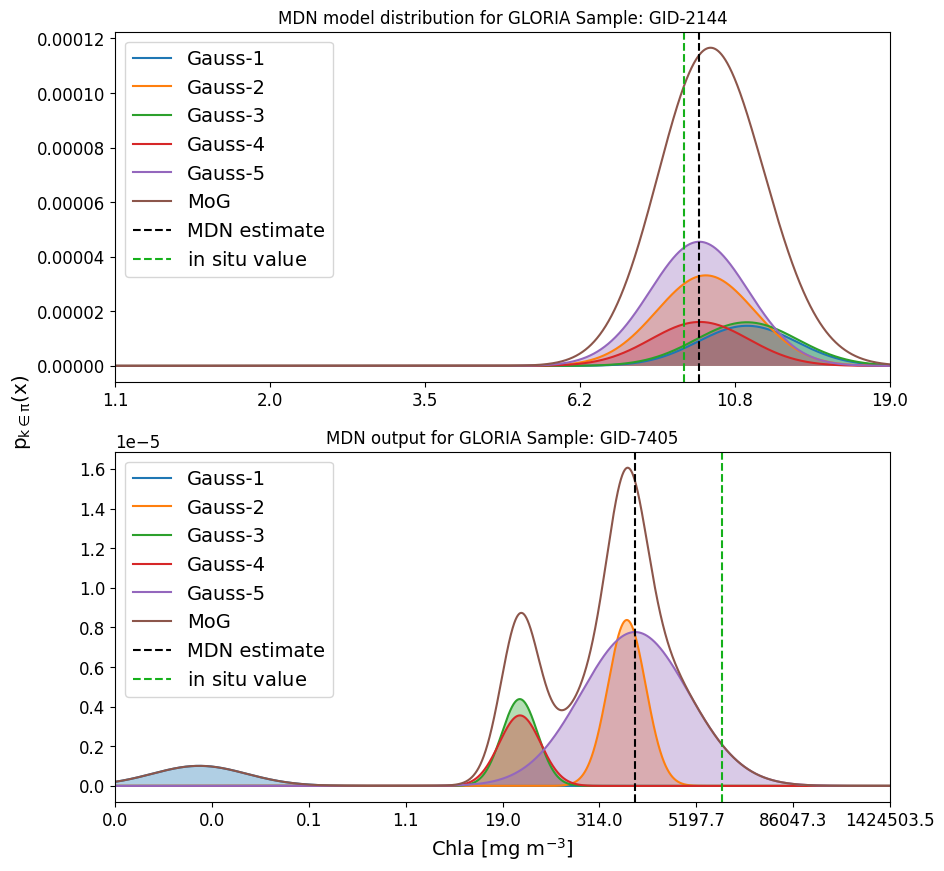

In [ ]:
# Create a new figure to hold this information
fig3, ax = plt.subplots(2, 1, figsize= (10, 10))
lims_plot  = [[-0.5, -0.0], [-2, 2]]
ticks_range = [0.1, 0.5]
title_list = ["MDN model distribution for GLORIA Sample: " + gid_data[idx_1][0].replace('_', '-'), "MDN output for GLORIA Sample: " + gid_data[idx_2][0].replace('_', '-')]
ins_val = [y_data[idx_1], y_data[idx_2]]

scalery = mdn_preds_full['scalery'][0]
for ctr in range(2):
    # Get the different MoG components
    weights = np.squeeze(mdn_preds_full['coefs'][0][0][ctr, :])
    mu = np.squeeze(mdn_preds_full['coefs'][0][1][ctr, :])
    var = np.squeeze(mdn_preds_full['coefs'][0][2][ctr, :])     # we are squeezing this down as in this case we a univariate model
    # Create a variable to hold the distribution
    y_prob = None
    for ii in range(5):
        # Sum this component into the overall distribution
        x_values = np.arange(-2, 2, 1.e-5)
        y_pdf = scipy.stats.norm(mu[ii], np.sqrt(var[ii]))
        y_values = y_pdf.pdf(x_values)
        y_values = y_values / y_values.sum()

        if y_prob is None:
            y_prob = weights[ii] * y_values
        else:
            y_prob += (weights[ii] * y_values)

        # Plot this specific component also
        loc = ticker.LinearLocator(numticks=int(round((lims_plot[ctr][1] - lims_plot[ctr][0])/ticks_range[ctr])+1))
        fmt = ticker.FuncFormatter(lambda i, _: r"%1.1f" % (scalery.inverse_transform(i*np.ones((1,1)))))

        ax[ctr].fill_between(np.squeeze(x_values), 0, weights[ii]*y_values, alpha=0.35)
        ax[ctr].plot(np.squeeze(x_values), weights[ii]*y_values, linewidth=1.5, label=f"Gauss-{ii+1}")
        

    # Normalize the overall distribution and plot it
    y_prob = y_prob/y_prob.sum()
    ax[ctr].plot(np.squeeze(x_values), y_prob, linewidth=1.5, label="MoG")
    ax[ctr].axvline(x=mu[np.argmax(weights)], color='k', linestyle='--', label="MDN estimate")
    ax[ctr].axvline(x=scalery.transform(ins_val[ctr]), color='xkcd:green', linestyle='--', label=r"$in~situ$ value")
    ax[ctr].set_xlim(lims_plot[ctr])

    ax[ctr].set_title(title_list[ctr])
    ax[ctr].xaxis.set_major_locator(loc)
    ax[ctr].xaxis.set_major_formatter(fmt)
    if ctr == 1:
        ax[ctr].set_xlabel(r'Chla [$mg~m^{-3}$]')
    ax[ctr].legend()


fig2.supylabel(r'p$_{k \in \pi}$(x)');            
                             

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<p style="font-size: 1.1em; color: #222222;">
Because a Mixture Density Network (MDN) predicts an entire probability distribution rather than a single number, we must decide how to collapse that distribution into a <b>final point estimate</b>.
</p>

<p style="font-size: 1.1em; color: #222222;">
In multi-modal systems, simply taking the global mean of the entire mixture can be misleading, as it might fall in a low-probability "valley" between two peaks. Instead, a robust approximation is to select the <b>dominant mode</b>—the peak representing the most likely state of the water column.
</p>

<h4 style="color: #004080; margin-top: 20px; font-weight: 700;">Selection Logic: The Maximum-Weight Component</h4>
<p style="font-size: 1.05em; color: #222222;">
To derive our final prediction, we identify the Gaussian component with the highest mixing coefficient (πk​). This component represents the model's primary hypothesis for the target value:
</p>

<ul style="padding-left: 25px; font-size: 1.05em; color: #222222;">
<li><b>Weight Identification:</b> We find the index k that maximizes the weight: kmax​=argmax(π1​,π2​,...,πK​).</li>
<li><b>Mean Extraction:</b> The final predicted value is defined as the mean (μ) associated with that specific dominant component.</li>
</ul>

<div style="background-color: #fcf8e3; color: #8a6d3b; padding: 15px; border: 1px solid #faebcc; border-left: 6px solid #8a6d3b; margin: 25px 0;">
<strong style="font-size: 1.1em;">Technical Note:</strong>
While more complex methods like <i>expectation-maximization</i> or <i>numerical mode-seeking</i> exist, selecting the mean of the dominant component is a computationally efficient and reasonable approximation for operational ocean color products.
</div>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 5: Quantitative Uncertainty Estimation
</h2>

<p style="font-size: 1.1em; color: #222222;">
    One of the most powerful features of the Mixture Density Network is its ability to quantify its own confidence. Unlike traditional regression models that provide only a point estimate, the MDN characterizes the <b>full output distribution</b> for every individual spectrum.
</p>

<p style="font-size: 1.1em; color: #222222;">
    In this workflow, we define <b>Uncertainty</b> as the spread of the predicted probability distribution. By calculating the <b>Standard Deviation (&sigma;)</b> of the mixture, we can assign a "per-sample" reliability metric to our biogeochemical retrievals.
</p>

<h4 style="color: #004080; margin-top: 20px; font-weight: 700;">The Technical Background</h4>

<p style="font-size: 1.1em; color: #222222;">
    As demonstrated by <b>Choi et al. (2017)</b>, the total variance of the Mixture of Gaussians (MoG) effectively encodes the model's confidence through two distinct physical components:
</p>

<ul style="padding-left: 25px; font-size: 1.05em; color: #222222;">
    <li style="margin-bottom: 10px;">
        <b>Expectation of Variance (Aleatoric Uncertainty):</b> This captures inherent noise and randomness within the data itself. It represents the "shaky ruler" effect—even if the model understands the water type, the sensor noise creates a baseline level of imprecision.
    </li>
    <li style="margin-bottom: 10px;">
    <b>Variance of Expectations (Epistemic Uncertainty):</b> This acts as a <b>"Conflict Metric."</b> It measures the dispersion or disagreement between different predicted means. When the model encounters  <b>Out-of-Distribution (OOD)</b> samples or extreme atmospheric distortions, the different Gaussian components "scatter," signaling that the model lacks the specific knowledge to provide a consensus answer. Crucially, this component also accounts for the <b>inverse nature of the problem</b>: in cases of genuine optical ambiguity, a high Variance of Expectations reveals that multiple distinct biogeochemical states could produce the same observed <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> spectrum.
</li>
</ul>



<center>
<div style="border: 2px solid #2c3e50; padding: 15px; border-radius: 8px; width: fit-content; background-color: #f9f9f9; margin: 25px 0;">
    <img src="images/mdn_input_output_uncertainty.jpg" alt="MDN I/O and uncertainty" style="max-width: 100%; height: auto; display: block; margin-bottom: 10px; border: 1px solid #ddd;" />
    <div style="text-align: center; font-family: 'Segoe UI', Arial, sans-serif; font-size: 14px; color: #555; font-weight: 600;">
        Fig. 1: Visualizing the MDN Input-Output pair and the dual-component method for estimating prediction uncertainty.
    </div>
</div>
</center>

<p style="font-size: 1.1em; color: #222222;">
    Research by <b>Saranathan et al. (2023)</b> highlights that these uncertainty metrics correlate strongly with estimation residuals. High uncertainty often flags data anomalies such as extreme atmospheric correction errors. To ensure product quality, our toolbox allows for <b>uncertainty masking</b>, typically filtering out predictions where the total &sigma; exceeds 100% of the retrieved value.
</p>

<h4 style="color: #004080; margin-top: 20px; font-weight: 700;">Practical Use of this Metric</h4>

<ul style="padding-left: 25px; font-size: 1.05em; color: #222222;">
    <li><b>High Confidence:</b> A narrow, sharp Gaussian peak indicates the model has reached a consensus on the constituent concentration.</li>
    <li><b>Low Confidence:</b> A broad or "multi-modal" distribution indicates the spectral signature is ambiguous or the water type was not well-represented during training.</li>
    <li><b>Quality Flagging:</b> This metric allows us to identify where retrievals are likely to be most accurate or where environmental conditions (like bottom reflectance or glint) are interfering with the signal.</li>
</ul>

<div style="background-color: #f4eefd; color: #5b2c91; padding: 15px; border: 1px solid #e1d5f5; border-left: 6px solid #5b2c91; margin: 25px 0;">
    <strong style="font-size: 1.1em;">Implementation:</strong>
    In the following steps, we will extract the standard deviation for each prediction and visualize it alongside our estimates to evaluate the statistical reliability of the MDN output.
</div>

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 1.5
</div>

</div>

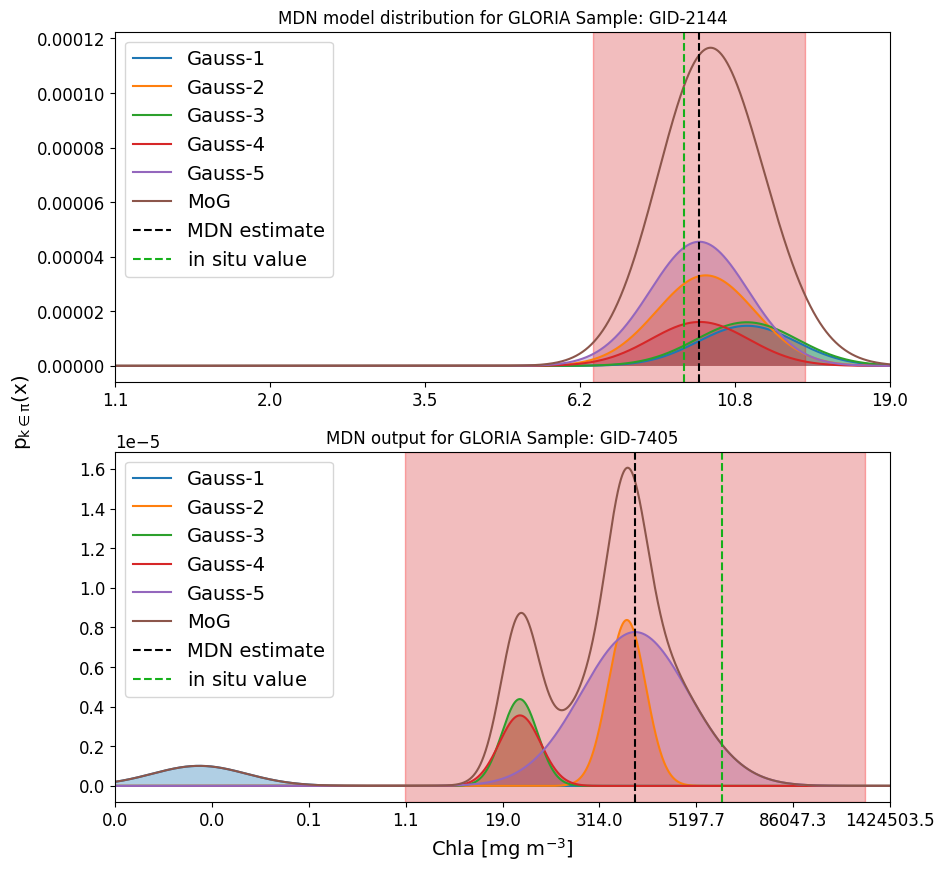

In [27]:
# Create a new figure to hold this information
fig3, ax = plt.subplots(2, 1, figsize= (10, 10))
lims_plot  = [[-0.5, -0.0], [-2, 2]]
ticks_range = [0.1, 0.5]
title_list = ["MDN model distribution for GLORIA Sample: " + gid_data[idx_1][0].replace('_', '-'), "MDN output for GLORIA Sample: " + gid_data[idx_2][0].replace('_', '-')]
ins_val = [y_data[idx_1], y_data[idx_2]]

scalery = mdn_preds_full['scalery'][0]
for ctr in range(2):
    # Get the different MoG components
    weights = np.squeeze(mdn_preds_full['coefs'][0][0][ctr, :])
    mu = np.squeeze(mdn_preds_full['coefs'][0][1][ctr, :])
    var = np.squeeze(mdn_preds_full['coefs'][0][2][ctr, :])     # we are squeezing this down as in this case we a univariate model
    # Create a variable to hold the distribution
    y_prob = None
    for ii in range(5):
        # Sum this component into the overall distribution
        x_values = np.arange(-2, 2, 1.e-5)
        y_pdf = scipy.stats.norm(mu[ii], np.sqrt(var[ii]))
        y_values = y_pdf.pdf(x_values)
        y_values = y_values / y_values.sum()

        if y_prob is None:
            y_prob = weights[ii] * y_values
        else:
            y_prob += (weights[ii] * y_values)

        # Plot this specific component also
        loc = ticker.LinearLocator(numticks=int(round((lims_plot[ctr][1] - lims_plot[ctr][0])/ticks_range[ctr])+1))
        fmt = ticker.FuncFormatter(lambda i, _: r"%1.1f" % (scalery.inverse_transform(i*np.ones((1,1)))))

        ax[ctr].fill_between(np.squeeze(x_values), 0, weights[ii]*y_values, alpha=0.35)
        ax[ctr].plot(np.squeeze(x_values), weights[ii]*y_values, linewidth=1.5, label=f"Gauss-{ii+1}")
        

    # Normalize the overall distribution and plot it
    y_prob = y_prob/y_prob.sum()
    ax[ctr].plot(np.squeeze(x_values), y_prob, linewidth=1.5, label="MoG")
    ax[ctr].axvline(x=mu[np.argmax(weights)], color='k', linestyle='--', label="MDN estimate")
    ax[ctr].axvline(x=scalery.transform(ins_val[ctr]), color='xkcd:green', linestyle='--', label=r"$in~situ$ value")
    y_min, y_max = ax[ctr].get_ylim()
    x_start, x_end = (mu[np.argmax(weights)] - (1.*mdn_uncert_full['comp_unc'][0][ctr])).item(), (mu[np.argmax(weights)] + (1.*mdn_uncert_full['comp_unc'][0][ctr])).item()
    rectangle = patches.Rectangle((x_start, y_min), x_end - x_start, y_max - y_min, linewidth=1, edgecolor='r', facecolor='tab:red', alpha=0.3)
    ax[ctr].add_patch(rectangle)
    ax[ctr].legend()
    ax[ctr].set_xlim(lims_plot[ctr])
    ax[ctr].set_title(title_list[ctr])
    ax[ctr].xaxis.set_major_locator(loc)
    ax[ctr].xaxis.set_major_formatter(fmt)
    if ctr == 1:
        ax[ctr].set_xlabel(r'Chla [$mg~m^{-3}$]')
    ax[ctr].legend()


fig3.supylabel(r'p$_{k \in \pi}$(x)');            
                             

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<p style="font-size: 1.1em; color: #222222;">
    The plots above visualize the region of uncertainty estimated using the distribution standard deviation on either side of the approximate maximum likelihood estimate (an interval of <b>2σ</b>). It is heartening to note that for these examples, the true value falls inside this region, indicating that the model-estimated uncertainty acts as a reliable <b>upper bound on prediction error</b>.
</p>

<p style="font-size: 1.1em; color: #222222;">
    This is not merely a function of the specific examples chosen. As demonstrated in <b>Saranathan et al. (2024)</b>, even when using a tighter uncertainty bound of <b>σ</b> (0.5σ on either side of the point estimate), the metric proved to be an upper bound on error for <b>75-80% of test samples</b>—data the model never encountered during training.
</p>

<h4 style="color: #004080; margin-top: 20px; font-weight: 700;">The Impact of Non-Linear Scaling</h4>

<p style="font-size: 1.1em; color: #222222;">
    While the uncertainty regions appear symmetric in the plots, the x-axis changes exponentially. Consequently, the right side of the uncertainty rectangle covers a larger physical range of values than the left. This visual distortion is a direct result of using a <b>non-linear scaler</b> on the output variables.
</p>

<div style="background-color: #f4eefd; color: #5b2c91; padding: 15px; border: 1px solid #e1d5f5; border-left: 6px solid #5b2c91; margin: 25px 0;">
    <strong style="font-size: 1.1em;">Technical Note on Approximation:</strong><br>
    Since we cannot directly invert &sigma; using a scaler, we employ an approximate process. Given y&#770; (the scaled MDN prediction) and &sigma; (the MoG standard deviation), we inverse-scale the points $(y&#770; - &sigma;)$ and $(y&#770; + &sigma;)$. The approximate scaled uncertainty is then estimated as the difference between these two points. In practical app
</div>

<h4 style="color: #c0392b; margin-top: 20px; font-weight: 700; border-bottom: 1px solid #eee;">References</h4>

<div style="font-size: 0.95em; color: #333; line-height: 1.4;">
    <p><a href="https://doi.org/10.3389/frsen.2024.1383147" style="color: #004080; text-decoration: none; font-weight: 600;">Assessment of advanced neural networks for the dual estimation of water quality indicators and their uncertainties</a>. A. M. Saranathan et al. (2024). <i>Frontiers in Remote Sensing</i>.</p>
    
    <p>2. <a href="https://doi.org/10.1109/TGRS.2023.3234465" style="color: #004080; text-decoration: none; font-weight: 600;">Per-Pixel Uncertainty Quantification and Reporting for Satellite-Derived Chlorophyll-a Estimates via Mixture Density Networks</a>. A. M. Saranathan et al. (2023). <i>IEEE TGRS</i>.</p>
    
    <p>3. <a href="https://doi.org/10.1109/ICRA.2018.8462978" style="color: #004080; text-decoration: none; font-weight: 600;">Uncertainty-aware learning from demonstration using mixture density networks with sampling-free variance modeling</a>. Choi (2017). <i>IEEE ICRA</i>.</p>
</div>

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right; margin-top: 15px;">
    Aquaverse Short Course • Module 1.5
</div>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #004080; border-bottom: 3px solid #004080; padding-bottom: 10px; font-weight: 800; margin-top: 0;">
    Conclusion: Harnessing MDN's Probabilistic Retrievals
</h2>

<p style="font-size: 1.15em; color: #222222;">
    In this module, we have transitioned from traditional point-estimate regression to the <b>Mixture Density Network (MDN)</b> framework. By treating water quality retrieval as a probabilistic task, we have gained the ability to not only predict biogeochemical constituents from <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> but also to understand the <b>reliability</b> of those predictions.
</p>

<h3 style="color: #004080; margin-top: 25px;"><b>Key Takeaways</b></h3>
<ul style="line-height: 1.9; color: #1a1a1a; list-style-type: none; padding-left: 0;">
    <li><span style="color: #27ae60;">✔</span> <b>Statistical Rigor:</b> You have successfully navigated the GLORIA dataset and implemented the SSAI MDN architecture.</li>
    <li><span style="color: #27ae60;">✔</span> <b>Uncertainty as a Tool:</b> We demonstrated that the 2σ interval serves as a robust upper bound for prediction error, vital for quality flagging in operational workflows.</li>
    <li><span style="color: #27ae60;">✔</span> <b>Scalability:</b> These techniques form the backbone of the NASA STREAM pipeline, providing a pathway from raw satellite measurements to actionable, uncertainty-aware aquatic information.</li>
</ul>

<div style="background-color: #e8f4fd; color: #2c3e50; padding: 15px; border: 1px solid #d1e9f9; border-left: 6px solid #004080; margin: 25px 0;">
    <strong style="font-size: 1.1em;">What's Next?</strong><br>
    In <b>Aquaverse Part II</b>, we will explore the application of these MDN models to multi-temporal satellite imagery (Landsat-8/9 and Sentinel-2) and discuss the impact of atmospheric correction residuals on our uncertainty metrics.
</div>

<hr style="border: 0; border-top: 2px solid #eee;">

<div style="display: flex; justify-content: space-between; align-items: center; margin-top: 20px;">
    <div>
        <strong style="color: #004080; font-size: 1.1em;">Freshwater Sensing Group</strong><br>
        <span style="color: #666; font-size: 0.95em;">SSAI / NASA Goddard Space Flight Center</span>
    </div>
    <div style="text-align: right;">
        <span style="font-size: 0.9em; color: #999; font-style: italic;">End of Module 1.5</span><br>
        <a href="https://ladsweb.modaps.eosdis.nasa.gov/stream/" target="_blank" style="color: #0056b3; font-weight: bold; text-decoration: none; font-size: 0.9em;">Visit STREAM Website →</a>
    </div>
</div>

</div>